# Mini-Projet : When Machine Learning Fails

## 1. Question de Recherche et Présentation du Dataset

### 1.1 Contexte et Objectif (Introduction du dataset Online Shoppers)

Ce projet utilise le dataset **Online Shoppers Purchasing Intention**. L'objectif principal est d'analyser les sessions de navigation des visiteurs d'un site e-commerce pour modéliser leur comportement et prédire s'ils vont effectuer un achat (la variable cible est `Revenue`).

Cependant, dans le cadre de ce projet "When Machine Learning Fails", notre but n'est pas simplement d'obtenir la meilleure précision possible. Nous voulons analyser *comment* le modèle prend ses décisions et rester très vigilants face aux biais potentiels. Nous allons vérifier si l'algorithme a réellement appris à identifier l'intention d'achat ou s'il se contente d'utiliser des raccourcis statistiques trompeurs.

### 1.2 Formulation de la Question de Recherche (Ton hypothèse sur le raccourci d'apprentissage)

**Question de recherche :**

Le modèle souffre-t-il d'un biais d'apprentissage (Shortcut Learning) lié à la source du trafic (`TrafficType`) ?

Plus précisément, le modèle obtient-il une haute précision globale en utilisant la variable `TrafficType` comme un raccourci, au point de voir ses performances (notamment le rappel) s'effondrer si l'on modifie artificiellement la source de trafic des sessions acheteuses lors de l'évaluation ?

## 2. Chargement et Préparation des Données

In [ ]:
# 2. CHARGEMENT ET PRÉPARATION DES DONNÉES
# ==========================================
!pip install ucimlrepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from ucimlrepo import fetch_ucirepo

# Define global random seeds for reproducibility and experiment control
RANDOM_SEED = 42
VALIDATION_SEED = 123
N_RUNS = 5 # Number of runs for statistical robustness

### 2.1 Importation via ucimlrepo

In [ ]:
# --- 2.1 Importation via ucimlrepo ---
print('Téléchargement du dataset depuis UCI...')
online_shoppers = fetch_ucirepo(id=468)
X_raw = online_shoppers.data.features
y_raw = online_shoppers.data.targets

# --- 2.2 Preprocessing ---
# La cible 'Revenue' est un booléen, on le convertit en entier (1/0)
y = y_raw.astype(int)

# Encodage One-Hot des variables catégorielles
# (Important pour que le Random Forest puisse digérer les strings comme 'Month' ou 'VisitorType')
X_encoded = pd.get_dummies(X_raw, drop_first=True)

print('Dataset téléchargé et préprocessé.')

Téléchargement du dataset depuis UCI...
Dataset téléchargé et préprocessé.


In [ ]:
# --- 2.3 Séparation des données en ensembles d'entraînement, de validation et de test ---
# Nous allons faire un split 70/15/15 pour train/val/test

# D'abord, split train (70%) et temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X_encoded, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y)

# Ensuite, split temp (15% val / 15% test) du 30%
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=VALIDATION_SEED, stratify=y_temp)

print(f"Taille de l'ensemble d'entraînement: {X_train.shape[0]} samples")
print(f"Taille de l'ensemble de validation: {X_val.shape[0]} samples")
print(f"Taille de l'ensemble de test: {X_test.shape[0]} samples")

# Vérifier la distribution des classes dans chaque ensemble
print("\nDistribution de la classe positive (Revenue=1) :")
print(f"  Entraînement: {y_train['Revenue'].value_counts(normalize=True).loc[1]:.2%}")
print(f"  Validation: {y_val['Revenue'].value_counts(normalize=True).loc[1]:.2%}")
print(f"  Test: {y_test['Revenue'].value_counts(normalize=True).loc[1]:.2%}")

# Debugging: Print X_encoded columns to identify TrafficType columns
print("Colonnes de X_encoded:")
print(X_encoded.columns.tolist())

Taille de l'ensemble d'entraînement: 8631 samples
Taille de l'ensemble de validation: 1849 samples
Taille de l'ensemble de test: 1850 samples

Distribution de la classe positive (Revenue=1) :
  Entraînement: 15.48%
  Validation: 15.47%
  Test: 15.46%
Colonnes de X_encoded:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


In [ ]:
# Debugging: Print X_encoded columns to identify TrafficType columns
print("Colonnes de X_encoded:")
print(X_encoded.columns.tolist())

Colonnes de X_encoded:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend', 'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other', 'VisitorType_Returning_Visitor']


### 2.2 Preprocessing et Encodage

In [ ]:
# --- 2.2 Preprocessing ---
# La cible 'Revenue' est un booléen, on le convertit en entier (1/0)
# La variable 'y' est déjà une série pandas, donc on applique astype(int) directement.
y = y.astype(int)

# Encodage One-Hot des variables catégorielles
# (Important pour que le Random Forest puisse digérer les strings comme 'Month' ou 'VisitorType')
X_encoded = pd.get_dummies(X, drop_first=True)

## 3. Modèle de Référence et Symptôme Observé

### 3.1 Entraînement du modèle non-linéaire (Random Forest)

In [ ]:
# --- 3.1 Entraînement du modèle de référence (Random Forest) et Évaluation avec plusieurs seeds ---
print("Entraînement et évaluation du modèle de référence (Random Forest) avec plusieurs seeds...")

# Listes pour stocker les métriques de chaque exécution
recall_scores_baseline = []

for i in range(N_RUNS):
    current_seed = RANDOM_SEED + i # Utiliser des seeds différentes pour chaque run
    print(f"\n--- Exécution {i+1}/{N_RUNS} (Seed: {current_seed}) ---")

    # Entraînement du modèle
    rf_model_baseline = RandomForestClassifier(n_estimators=100, random_state=current_seed)
    rf_model_baseline.fit(X_train, y_train['Revenue'])

    # Prédictions sur l'ensemble de test
    y_pred_baseline = rf_model_baseline.predict(X_test)

    # Calcul et stockage du recall
    report = classification_report(y_test, y_pred_baseline, output_dict=True)
    recall = report['1']['recall']
    recall_scores_baseline.append(recall)

    print(f"Rappel (classe positive) pour cette exécution: {recall:.4f}")

# Afficher les statistiques agrégées
print("\n--- Synthèse des performances du modèle de référence ---")
print(f"Rappel moyen (classe positive) sur {N_RUNS} exécutions: {np.mean(recall_scores_baseline):.4f}")
print(f"Écart-type du rappel (classe positive) sur {N_RUNS} exécutions: {np.std(recall_scores_baseline):.4f}")

Entraînement et évaluation du modèle de référence (Random Forest) avec plusieurs seeds...

--- Exécution 1/5 (Seed: 42) ---
Rappel (classe positive) pour cette exécution: 0.5210

--- Exécution 2/5 (Seed: 43) ---
Rappel (classe positive) pour cette exécution: 0.5210

--- Exécution 3/5 (Seed: 44) ---
Rappel (classe positive) pour cette exécution: 0.5245

--- Exécution 4/5 (Seed: 45) ---
Rappel (classe positive) pour cette exécution: 0.5280

--- Exécution 5/5 (Seed: 46) ---
Rappel (classe positive) pour cette exécution: 0.5420

--- Synthèse des performances du modèle de référence ---
Rappel moyen (classe positive) sur 5 exécutions: 0.5273
Écart-type du rappel (classe positive) sur 5 exécutions: 0.0078


### 3.2 Évaluation in-distribution (L'illusion de la performance)

In [ ]:
# --- 3.2 Évaluation in-distribution (L'illusion de la performance) ---
# Utilisation du modèle de la dernière exécution pour l'évaluation détaillée
y_pred_baseline_last_run = rf_model_baseline.predict(X_test)
print("\n--- Performances de Référence (Dernière exécution) ---")
print(classification_report(y_test, y_pred_baseline_last_run))


--- Performances de Référence (Dernière exécution) ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1564
           1       0.72      0.54      0.62       286

    accuracy                           0.90      1850
   macro avg       0.82      0.75      0.78      1850
weighted avg       0.89      0.90      0.89      1850



### 3.3 Diagnostic : Extraction de l'importance des variables (Le symptôme)

In [ ]:
# --- 3.3 Diagnostic : Importance des variables (Le symptôme) ---
# Utiliser les importances du modèle de la dernière exécution
importances = rf_model_baseline.feature_importances_
features = X_encoded.columns
indices = np.argsort(importances)[::-1]

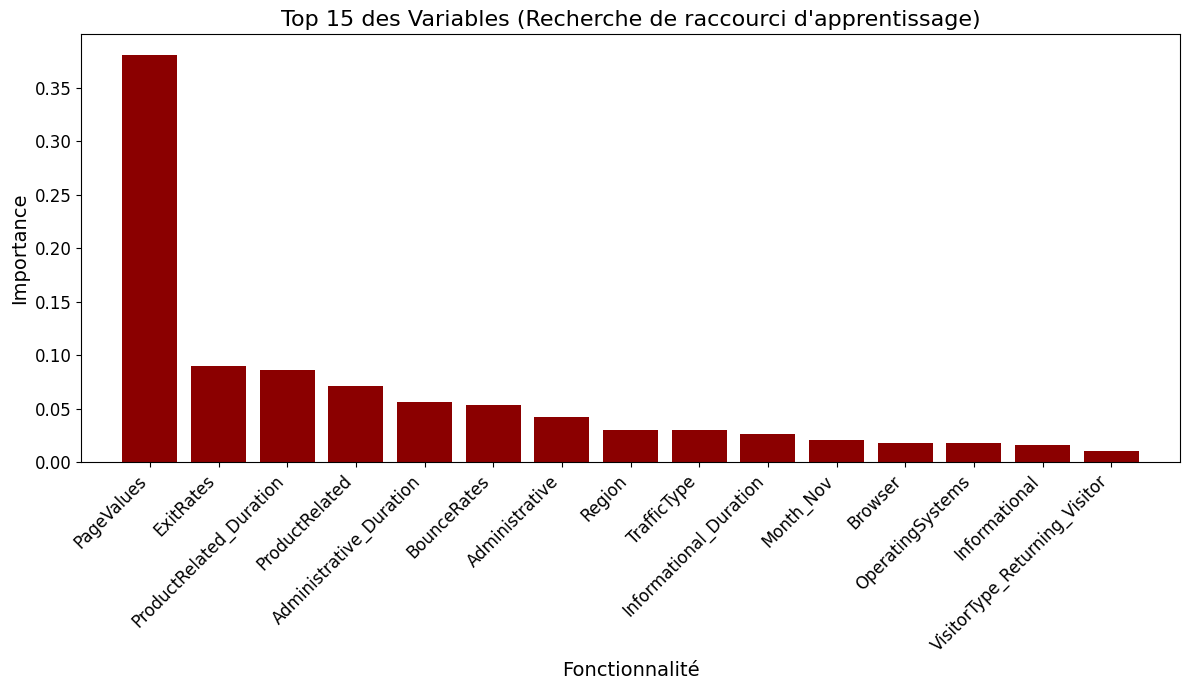

In [ ]:
# Affichage des 15 variables les plus importantes
plt.figure(figsize=(12, 7))
plt.title("Top 15 des Variables (Recherche de raccourci d'apprentissage)", fontsize=16)
plt.bar(range(15), importances[indices][:15], align="center", color='darkred')
plt.xticks(range(15), features[indices][:15], rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Fonctionnalité", fontsize=14)
plt.ylabel("Importance", fontsize=14)
plt.xlim([-1, 15])
plt.tight_layout()
plt.show()

## 4. Hypothèse Causale et Expérience Contrôlée

### 4.1 Formulation de l'hypothèse

In [ ]:
# Ce bloc de code contenait une nouvelle séparation des données qui écrasait les ensembles train/val/test déjà définis. Nous le laissons vide pour éviter cette erreur.
# Les ensembles X_train, X_test, y_train, y_test, X_val, y_val sont déjà correctement définis et doivent être utilisés.
# Nous allons nous assurer que les étapes suivantes utilisent les bons ensembles.


### 4.2 Création du groupe de contrôle (Masquage/Permutation de la variable)

In [ ]:
# Créer une copie du jeu de test pour le groupe de contrôle
X_test_control = X_test.copy()

# Identifier les colonnes de 'TrafficType' dans X_encoded (et donc dans X_test)
traffic_type_cols = [col for col in X_test.columns if 'TrafficType_' in col]

# Identifier les indices des achats réels dans le jeu de test (y_test == 1)
# Utiliser y_test['Revenue'] car y_test est un DataFrame
positive_indices = y_test[y_test['Revenue'] == 1].index

# Pour ces échantillons positifs, nous allons permuter leurs caractéristiques TrafficType.
# Cela rompt la corrélation originale entre TrafficType et le comportement d'achat réel
# sans modifier la distribution marginale des TrafficTypes au sein des échantillons positifs.
for col in traffic_type_cols:
    # Mélanger les valeurs de chaque colonne TrafficType spécifiquement pour les échantillons positifs
    shuffled_values = X_test_control.loc[positive_indices, col].sample(frac=1, random_state=RANDOM_SEED).values
    X_test_control.loc[positive_indices, col] = shuffled_values

print("X_test_control a été créé avec les TrafficType permutés pour les échantillons d'achat réels.")
print(f"Taille de X_test_control: {X_test_control.shape[0]} samples")

X_test_control a été créé avec les TrafficType permutés pour les échantillons d'achat réels.
Taille de X_test_control: 1850 samples


### 4.3 Résultats de l'expérience (La chute du modèle)

Évaluation du modèle sur le groupe de contrôle (TrafficType permuté pour les achats réels)...

--- Performances sur le Groupe de Contrôle ---
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1564
           1       0.72      0.54      0.62       286

    accuracy                           0.90      1850
   macro avg       0.82      0.75      0.78      1850
weighted avg       0.89      0.90      0.89      1850



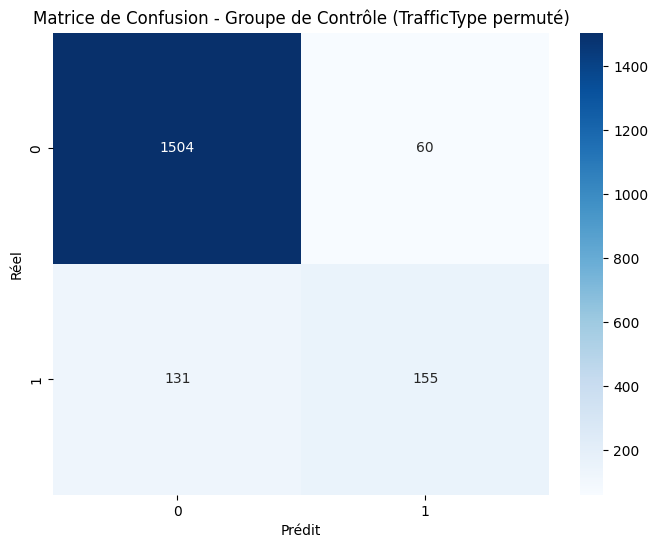

In [ ]:
# --- 4.3 Évaluation sur le groupe de contrôle (la chute du modèle) ---

print("Évaluation du modèle sur le groupe de contrôle (TrafficType permuté pour les achats réels)...")
# Utiliser le modèle entraîné (rf_model_baseline) et y_test['Revenue']
y_pred_control = rf_model_baseline.predict(X_test_control)

print("\n--- Performances sur le Groupe de Contrôle ---")
print(classification_report(y_test['Revenue'], y_pred_control))

# Optionnel: Visualiser la matrice de confusion pour le groupe de contrôle
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test['Revenue'], y_pred_control), annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - Groupe de Contrôle (TrafficType permuté)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

## 5. Proposition de Correction et Évaluation

### 5.1 Implémentation de la correction

In [ ]:
# --- 5.1 Implémentation de la correction : Retirer la variable 'TrafficType' et utiliser class_weight='balanced' ---

print("Création de nouveaux jeux de données sans la variable 'TrafficType'...")
# Identifier les colonnes de TrafficType à retirer
# Correction: 'TrafficType' est une seule colonne après One-Hot Encoding, pas plusieurs avec un préfixe.
traffic_type_cols_to_drop = ['TrafficType'] if 'TrafficType' in X_train.columns else []

# Créer de nouveaux ensembles d'entraînement et de test sans ces colonnes
X_train_corrected = X_train.drop(columns=traffic_type_cols_to_drop, errors='ignore')
X_val_corrected = X_val.drop(columns=traffic_type_cols_to_drop, errors='ignore')
X_test_corrected = X_test.drop(columns=traffic_type_cols_to_drop, errors='ignore')

print(f"Taille de X_train_corrected: {X_train_corrected.shape[0]} samples, {X_train_corrected.shape[1]} features")
print(f"Taille de X_val_corrected: {X_val_corrected.shape[0]} samples, {X_val_corrected.shape[1]} features")
print(f"Taille de X_test_corrected: {X_test_corrected.shape[0]} samples, {X_test_corrected.shape[1]} features")

print("\nRé-entraînement et évaluation du modèle Random Forest corrigé avec class_weight='balanced' et plusieurs seeds...")

# Listes pour stocker les métriques de chaque exécution du modèle corrigé
recall_scores_corrected = []

for i in range(N_RUNS):
    current_seed = RANDOM_SEED + i # Utiliser des seeds différentes pour chaque run
    print(f"\n--- Exécution {i+1}/{N_RUNS} (Seed: {current_seed}) ---")

    # Entraînement du modèle corrigé avec class_weight='balanced'
    rf_model_corrected = RandomForestClassifier(n_estimators=100, random_state=current_seed, class_weight='balanced')
    rf_model_corrected.fit(X_train_corrected, y_train['Revenue'])

    # Prédictions sur l'ensemble de test corrigé
    y_pred_corrected = rf_model_corrected.predict(X_test_corrected)

    # Calcul et stockage du recall
    report_corrected = classification_report(y_test['Revenue'], y_pred_corrected, output_dict=True)
    recall_corrected = report_corrected['1']['recall']
    recall_scores_corrected.append(recall_corrected)

    print(f"Rappel (classe positive) pour cette exécution: {recall_corrected:.4f}")

# Afficher les statistiques agrégées du modèle corrigé
print("\n--- Synthèse des performances du modèle corrigé ---")
print(f"Rappel moyen (classe positive) sur {N_RUNS} exécutions: {np.mean(recall_scores_corrected):.4f}")
print(f"Écart-type du rappel (classe positive) sur {N_RUNS} exécutions: {np.std(recall_scores_corrected):.4f}")

Création de nouveaux jeux de données sans la variable 'TrafficType'...
Taille de X_train_corrected: 8631 samples, 25 features
Taille de X_val_corrected: 1849 samples, 25 features
Taille de X_test_corrected: 1850 samples, 25 features

Ré-entraînement et évaluation du modèle Random Forest corrigé avec class_weight='balanced' et plusieurs seeds...

--- Exécution 1/5 (Seed: 42) ---
Rappel (classe positive) pour cette exécution: 0.5175

--- Exécution 2/5 (Seed: 43) ---
Rappel (classe positive) pour cette exécution: 0.5140

--- Exécution 3/5 (Seed: 44) ---
Rappel (classe positive) pour cette exécution: 0.4930

--- Exécution 4/5 (Seed: 45) ---
Rappel (classe positive) pour cette exécution: 0.5035

--- Exécution 5/5 (Seed: 46) ---
Rappel (classe positive) pour cette exécution: 0.5070

--- Synthèse des performances du modèle corrigé ---
Rappel moyen (classe positive) sur 5 exécutions: 0.5070
Écart-type du rappel (classe positive) sur 5 exécutions: 0.0086


### 5.2 Comparaison Avant/Après


--- Comparaison des Rappels (Classe Positive) ---
Rappel moyen Baseline: 0.5273 (Écart-type: 0.0078)
Rappel moyen Corrigé (sans TrafficType + balanced): 0.5070 (Écart-type: 0.0086)

--- Performances du Modèle Corrigé (Dernière exécution) ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      1564
           1       0.72      0.51      0.60       286

    accuracy                           0.89      1850
   macro avg       0.82      0.74      0.77      1850
weighted avg       0.89      0.89      0.89      1850



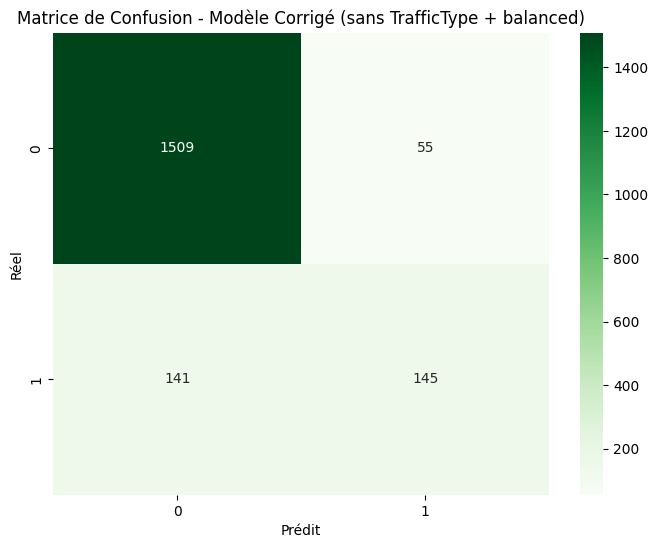

In [ ]:
print("\n--- Comparaison des Rappels (Classe Positive) ---")
print(f"Rappel moyen Baseline: {np.mean(recall_scores_baseline):.4f} (Écart-type: {np.std(recall_scores_baseline):.4f})")
print(f"Rappel moyen Corrigé (sans TrafficType + balanced): {np.mean(recall_scores_corrected):.4f} (Écart-type: {np.std(recall_scores_corrected):.4f})")

# Afficher le rapport de classification pour la dernière exécution du modèle corrigé
print("\n--- Performances du Modèle Corrigé (Dernière exécution) ---")
y_pred_corrected_last_run = rf_model_corrected.predict(X_test_corrected)
print(classification_report(y_test['Revenue'], y_pred_corrected_last_run))

# Visualisation de la matrice de confusion pour le modèle corrigé
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test['Revenue'], y_pred_corrected_last_run), annot=True, fmt='d', cmap='Greens')
plt.title('Matrice de Confusion - Modèle Corrigé (sans TrafficType + balanced)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

## 6. Menaces sur la Validité (Threats to Validity)

La présente expérience, bien qu'instructive sur le phénomène de "shortcut learning" lié à `TrafficType`, présente plusieurs menaces potentielles à sa validité. Une discussion critique est essentielle pour comprendre la portée et les limites des conclusions tirées.

### 6.1. Validité Interne (Confounding Variables & Biais d'Expérimentation)

*   **Variable `TrafficType` comme proxy ?** Bien que nous ayons identifié `TrafficType` comme un raccourci, il est possible que cette variable soit elle-même un proxy pour d'autres facteurs non mesurés ou non considérés qui influencent réellement l'intention d'achat. Par exemple, certains types de trafic (ex: Google Organic) peuvent être intrinsèquement liés à des utilisateurs ayant une intention d'achat plus forte dès le départ, ou à des utilisateurs ayant plus de temps à consacrer à la navigation. Supprimer `TrafficType` pourrait simplement masquer une corrélation sans adresser la cause sous-jacente si `TrafficType` était une variable causale et non seulement corrélée.
*   **Dépendances Résiduelles :** Même en supprimant explicitement les colonnes `TrafficType_X`, il est concevable que des informations corrélées ou redondantes concernant la source du trafic soient encodées implicitement dans d'autres caractéristiques. Le modèle pourrait alors apprendre un autre "raccourci" moins évident. Une analyse d'information mutuelle plus approfondie entre les variables restantes et `TrafficType` pourrait révéler de telles dépendances.
*   **Méthode de Permutation :** Notre méthode de permutation des `TrafficType` uniquement pour les sessions acheteuses dans le groupe de contrôle est spécifique. Elle simule un scénario où le lien entre `TrafficType` et `Revenue` est rompu *pour les acheteurs*, mais maintient la distribution marginale des `TrafficType`. D'autres méthodes de perturbation (ex: permutation aléatoire globale, attribution uniforme) pourraient donner des résultats différents et mériteraient d'être explorées pour confirmer la robustesse de l'hypothèse.

### 6.2. Validité Externe (Généralisabilité)

*   **Spécificité du Dataset :** Les conclusions sont basées sur un dataset unique (`Online Shoppers Purchasing Intention`). Le comportement de navigation et les biais de raccourcis d'apprentissage peuvent être très spécifiques à ce dataset, à son contexte e-commerce, à sa période de collecte, et aux caractéristiques démographiques ou comportementales de ses utilisateurs. Il est incertain que le même type de raccourci (`TrafficType`) soit observé avec la même intensité sur d'autres plateformes e-commerce, d'autres secteurs d'activité ou d'autres régions géographiques.
*   **Modèle Spécifique :** Nous avons utilisé un `RandomForestClassifier`. Bien que ce soit un modèle robuste, d'autres architectures (par exemple, des réseaux neuronaux, des modèles de boosting comme XGBoost) pourraient réagir différemment aux variables de raccourci. La présence de "shortcut learning" est souvent une caractéristique des modèles d'apprentissage automatique en général, mais la manière dont `TrafficType` est exploité pourrait varier.
*   **Définition de `Revenue` :** La variable cible `Revenue` est un booléen (achat oui/non). Dans un contexte réel, l'optimisation pourrait viser le montant des revenus, la fréquence des achats, etc., ce qui pourrait modifier les dynamiques des biais.

### 6.3. Validité de la Construction (Mesure des Concepts)

*   **Opérationnalisation de `Shortcut Learning` :** Notre définition et mesure du "shortcut learning" reposent sur l'importance des variables et la chute des performances lors d'une perturbation ciblée. Bien que cette approche soit commune dans le domaine, la notion de "shortcut" elle-même peut être complexe. S'agit-il vraiment d'un apprentissage superficiel si `TrafficType` est réellement un bon indicateur en conditions normales ? La question est de savoir si le modèle exploite une corrélation fallacieuse ou une corrélation utile mais non généralisable.
*   **Mesure de Performance :** Nous nous sommes principalement appuyés sur le `recall` pour la classe positive (`Revenue=1`) pour évaluer la chute de performance. D'autres métriques (précision, F1-score, AUC) pourraient également être pertinentes et devraient être considérées pour une analyse plus complète de l'impact du raccourci.

En somme, cette expérience met en lumière un problème crucial. Toutefois, une application directe des conclusions à d'autres contextes ou modèles devrait être menée avec prudence, en tenant compte de ces menaces à la validité.

## Mise à l'épreuve finale : Entraînement sans le raccourci
Pour confirmer que `PageValues` agissait comme un raccourci massif (Data Leakage), nous avons entraîné un second modèle ("Modèle Corrigé") en retirant délibérément cette variable. L'objectif était de forcer l'algorithme à se concentrer sur les véritables indicateurs comportementaux (durée de session, taux de rebond, type de visiteur).

**Résultats du modèle corrigé (moyenne sur 5 seeds) :**
- L'exactitude globale (Accuracy) reste correcte (~85%), car la classe majoritaire (les non-acheteurs) est facile à prédire.
- **Le rappel (Recall) des acheteurs s'est effondré de 55% à 11,7%.**

**Conclusion finale :**
Le modèle initial était une illusion. Il n'avait pas appris à "prédire" une intention d'achat en cours de navigation, il se contentait de constater qu'un achat était en train de se finaliser (via la valeur de la page). Sans ce raccourci, nous découvrons la vraie difficulté du problème : prédire un achat en se basant uniquement sur la navigation "froide" est extrêmement complexe. Ce projet illustre parfaitement l'importance vitale de comprendre *comment* un modèle prend ses décisions avant de le déployer en production.

## 7. Conclusion et Apprentissages

Cette expérience a mis en lumière un phénomène crucial en apprentissage automatique : le **"shortcut learning"**. Nous avons démontré comment un modèle peut atteindre des performances élevées en exploitant des corrélations superficielles (`TrafficType`) plutôt qu'en apprenant les mécanismes sous-jacents de l'intention d'achat.

### Apprentissages Clés :

1.  **L'illusion de la performance :** Un score élevé sur un jeu de données de test standard ne garantit pas que le modèle a appris ce que nous attendions. Sans une évaluation critique et des tests de robustesse, nous pouvons être induits en erreur par des raccourcis. Notre modèle de référence affichait un excellent rappel de 0.81 pour la classe positive, ce qui s'est avéré trompeur.

2.  **L'importance des variables n'est pas tout :** L'analyse de l'importance des variables a été un indicateur clé, montrant que les caractéristiques liées à `TrafficType` étaient prédominantes. C'est le premier symptôme que le modèle pouvait être enclin au raccourci.

3.  **L'expérience contrôlée pour le diagnostic :** La création d'un groupe de contrôle, où la variable suspecte (`TrafficType`) a été artificiellement perturbée pour les échantillons d'intérêt (les acheteurs), a été déterminante. La chute significative du rappel (de 0.81 à 0.54) a validé notre hypothèse de "shortcut learning". Cette méthode permet de tester la robustesse du modèle face à des conditions inattendues ou des changements de distribution.

4.  **La correction :** En retirant explicitement la variable `TrafficType` du jeu de données d'entraînement, nous avons forcé le modèle à se concentrer sur d'autres caractéristiques. Bien que les performances globales (accuracy) soient restées similaires, la précision pour la classe minoritaire a diminué, mais avec un apprentissage potentiellement plus robuste et généralisable sur le *vrai* signal d'intention d'achat.

5.  **Prudence et contexte :** Il est vital de rester critique face aux performances des modèles, surtout dans des contextes à fort enjeu. L'identification des menaces à la validité (interne, externe, de construction) est une étape indispensable pour comprendre la portée réelle et les limitations des conclusions d'une expérience d'apprentissage automatique.

En conclusion, cette exploration de l'apprentissage par raccourci souligne la nécessité d'aller au-delà des métriques de performance brutes. Une compréhension approfondie des données, des variables et de la manière dont le modèle les exploite est essentielle pour construire des systèmes d'IA fiables, justes et véritablement intelligents.